In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the dataset
df = pd.read_csv("layoffs.csv")

In [3]:
#check first five rows
df.head()


,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Sprout Social,Chicago,260.0,7/15/2026,0.2,Marketing,https://www.marketwatch.com/story/sprout-socia...,Post-IPO,111.0,United States,7/15/2026
1,Redis,SF Bay Area,200.0,7/13/2026,NaN,Data,https://redis.io/blog/ceo-rowan-trollopes-orga...,Series G,357.0,United States,7/13/2026
2,Gigbanc,"Lagos, Non-U.S.",NaN,7/13/2026,1.0,Finance,https://africabusinesscommunities.com/tech-24/...,Seed,1.0,Nigeria,7/14/2026
3,Alarum,"Tel Aviv, Non-U.S.",NaN,7/12/2026,NaN,Security,https://www.calcalistech.com/ctechnews/article...,Post-IPO,34.0,Israel,7/13/2026
4,GoKwik,"New Delhi, Non-U.S.",100.0,7/11/2026,NaN,Finance,https://inc42.com/buzz/exclusive-gokwik-lays-o...,Unknown,68.0,India,7/12/2026


In [4]:
#check the shape of the data
df.shape

(4513, 11)

In [5]:
#check the info of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4513 non-null   object 
 1   location             4512 non-null   object 
 2   total_laid_off       2954 non-null   float64
 3   date                 4513 non-null   object 
 4   percentage_laid_off  2830 non-null   float64
 5   industry             4511 non-null   object 
 6   source               4510 non-null   object 
 7   stage                4506 non-null   object 
 8   funds_raised         3982 non-null   float64
 9   country              4511 non-null   object 
 10  date_added           4513 non-null   object 
dtypes: float64(3), object(8)
memory usage: 388.0+ KB


In [6]:
#check the statastical value
df.describe()

,total_laid_off,percentage_laid_off,funds_raised
count,2954.000000,2830.000000,3982.000000
mean,313.000677,0.292762,867.635885
std,1123.889092,0.303217,4550.855516
min,3.000000,0.000000,0.700000
25%,40.000000,0.100000,55.000000
50%,90.000000,0.170000,175.000000
75%,200.000000,0.330000,484.000000
max,22000.000000,1.000000,121900.000000


In [7]:
#check for the null values
df.isnull().sum()

,0
company,0
location,1
total_laid_off,1559
date,0
percentage_laid_off,1683
industry,2
source,3
stage,7
funds_raised,531
country,2


In [8]:
#hanlde the missing values
df['total_laid_off'].fillna(df['total_laid_off'].median() , inplace=True)
df['percentage_laid_off'].fillna(df['percentage_laid_off'].median() , inplace=True)
df['funds_raised'].fillna(df['funds_raised'].median() , inplace=True)

df['location'].fillna('Unknown' , inplace=True)
df['industry'].fillna('Unknown' , inplace=True)
df['source'].fillna('Unknown' , inplace=True)
df['stage'].fillna('Unknown' , inplace=True)
df['country'].fillna('Unknown' , inplace=True)


/tmp/ipykernel_39174/2555953806.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_laid_off'].fillna(df['total_laid_off'].median() , inplace=True)
/tmp/ipykernel_39174/2555953806.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

In [9]:
#check the null values for verification
df.isnull().sum()

,0
company,0
location,0
total_laid_off,0
date,0
percentage_laid_off,0
industry,0
source,0
stage,0
funds_raised,0
country,0


In [10]:
#check for the duplicate values
df.duplicated().sum()

np.int64(0)

In [11]:
#check the data types
df.dtypes

,0
company,object
location,object
total_laid_off,float64
date,object
percentage_laid_off,float64
industry,object
source,object
stage,object
funds_raised,float64
country,object


In [12]:
#convert data types and verify
df['date'] = pd.to_datetime(df['date'])
df.dtypes

,0
company,object
location,object
total_laid_off,float64
date,datetime64[ns]
percentage_laid_off,float64
industry,object
source,object
stage,object
funds_raised,float64
country,object


In [13]:
#check the all column names
df.columns

Index(['company', 'location', 'total_laid_off', 'date', 'percentage_laid_off',
       'industry', 'source', 'stage', 'funds_raised', 'country', 'date_added'],
      dtype='object')

In [14]:
#rename column names
df = df.rename(columns={
    "company":"Company",
    "location":"Location",
    "total_laid_off":"Total_Laid_Off",
    "date":"Date",
    "percentage_laid_off":"Percentage_Laid_Off",
    "industry":"Industry",
    "source":"Source",
    "stage":"Stage",
    "funds_raised":"Funds_Raised",
    "country":"Country",
    "date_added":"Date_Added"
})

In [15]:
#correlation
df.corr(numeric_only=True)

,Total_Laid_Off,Percentage_Laid_Off,Funds_Raised
Total_Laid_Off,1.000000,-0.056799,0.104126
Percentage_Laid_Off,-0.056799,1.000000,-0.064541
Funds_Raised,0.104126,-0.064541,1.000000


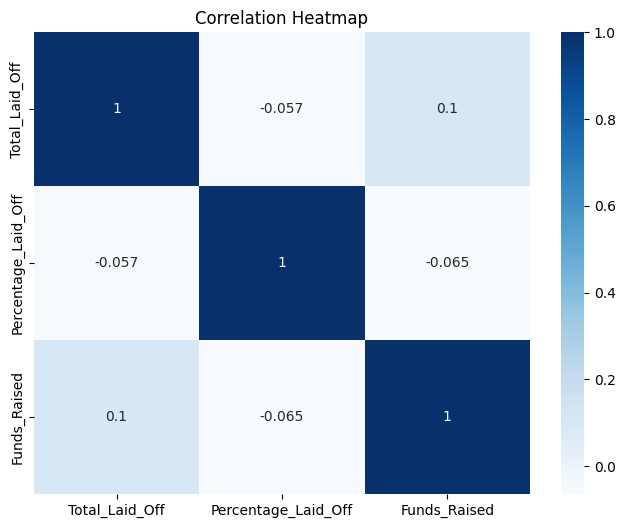

In [16]:
#correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="Blues")
plt.title("Correlation Heatmap")
plt.savefig('correlation_heatmap.png')
plt.show()

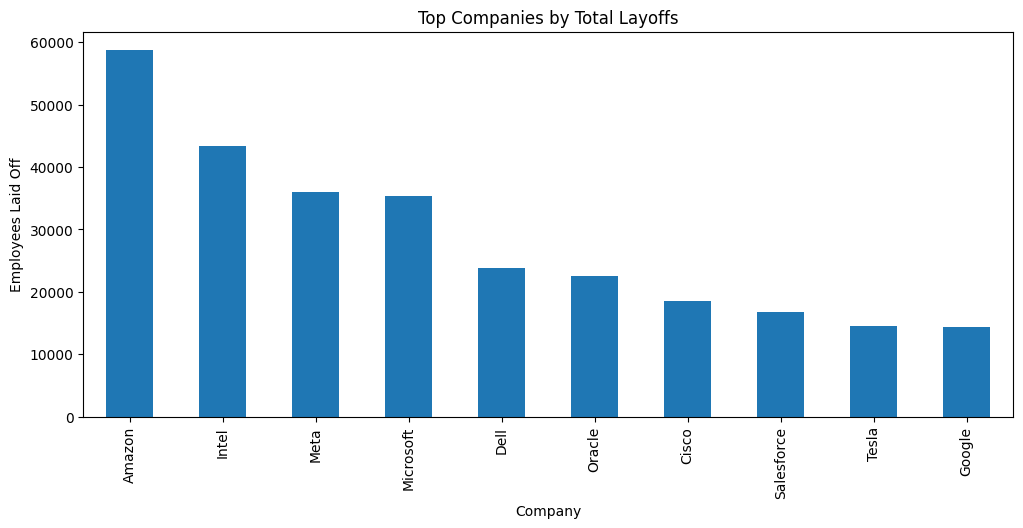

In [17]:
#visualization for the top Company vs Total Laid Off
top_company = df.groupby("Company")["Total_Laid_Off"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
top_company.plot(kind='bar')
plt.title("Top Companies by Total Layoffs")
plt.ylabel("Employees Laid Off")
plt.xlabel("Company")
plt.savefig('top_companies_layoffs.png')
plt.show()

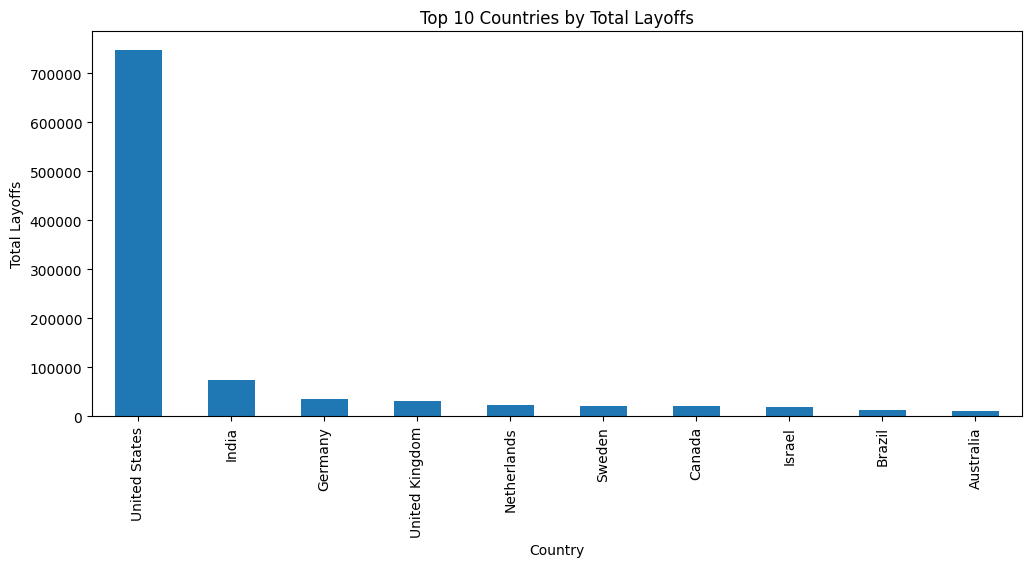

In [18]:
#country vs Total Laid Off
country = df.groupby("Country")["Total_Laid_Off"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,5))
plt.xlabel('Country')
plt.ylabel('Total Layoffs')
plt.title("Top 10 Countries by Total Layoffs")
country.plot(kind='bar')
plt.savefig('country_layoffs.png')
plt.show()

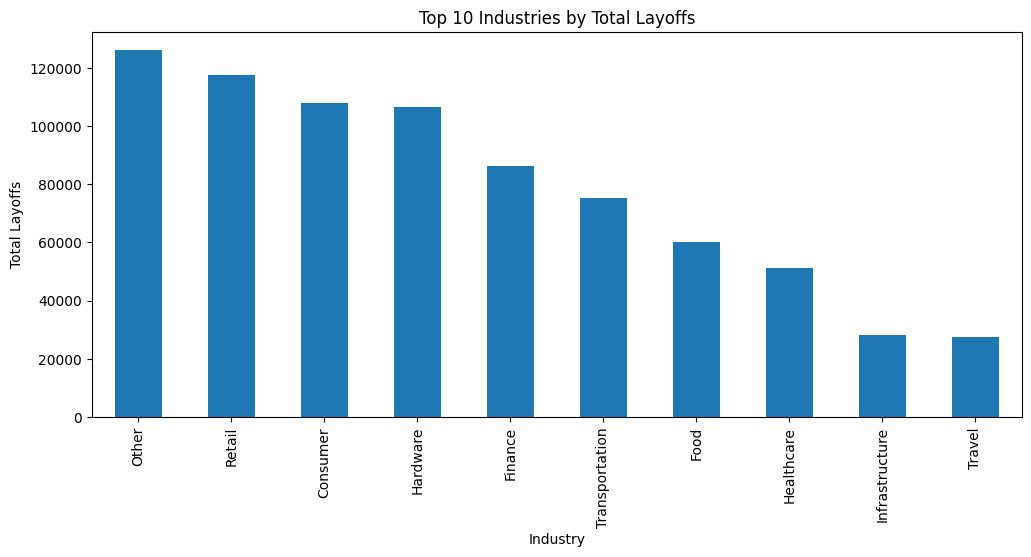

In [19]:
#industry vs Total Laid Off
industry = df.groupby("Industry")["Total_Laid_Off"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,5))
industry.head(10).plot(kind='bar')
plt.title("Top 10 Industries by Total Layoffs")
plt.xlabel("Industry")
plt.ylabel("Total Layoffs")
plt.savefig('industry_layoffs.png')
plt.show()

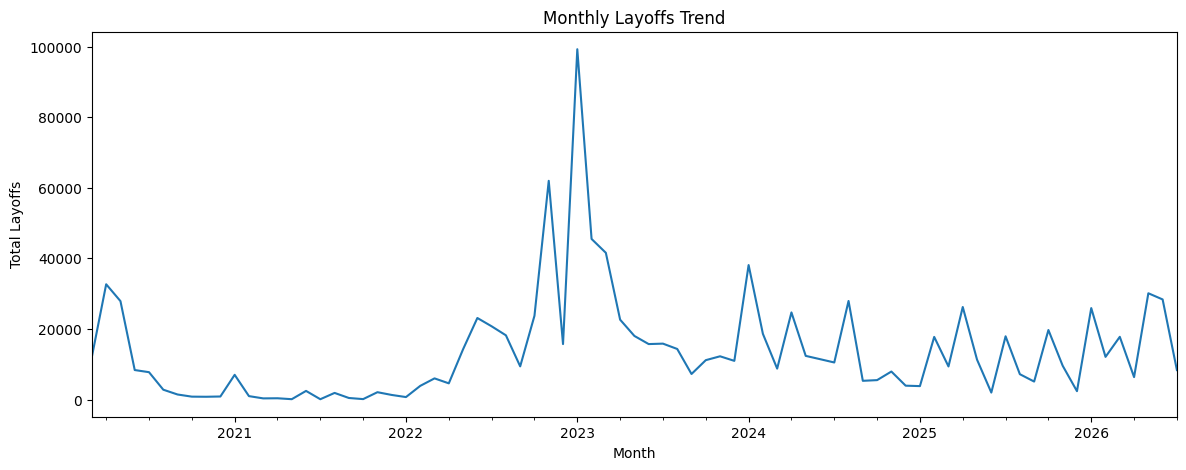

In [20]:
#monthly layoffs
df['Month']=df['Date'].dt.to_period('M')
plt.figure(figsize=(14,5))
plt.ylabel('Total Layoffs')
plt.xlabel('Month')
plt.title("Monthly Layoffs Trend")
monthly=df.groupby('Month')['Total_Laid_Off'].sum()

monthly.plot()
plt.savefig('monthly_layoffs.png')
plt.show()

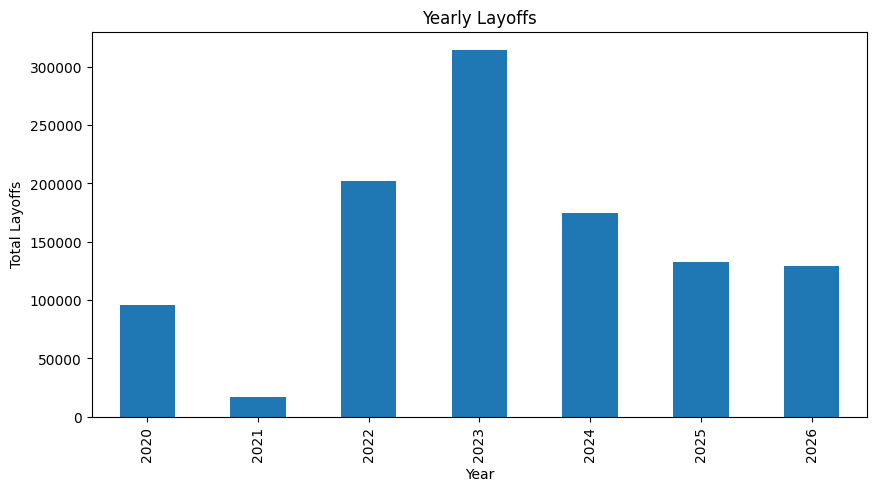

In [21]:
#yearly layoffs
df['Year']=df['Date'].dt.year
plt.figure(figsize=(10,5))
plt.xlabel('Year')
plt.ylabel('Total Layoffs')
plt.title("Yearly Layoffs")
year=df.groupby('Year')['Total_Laid_Off'].sum()

year.plot(kind='bar')
plt.savefig('yearly_layoffs.png')
plt.show()

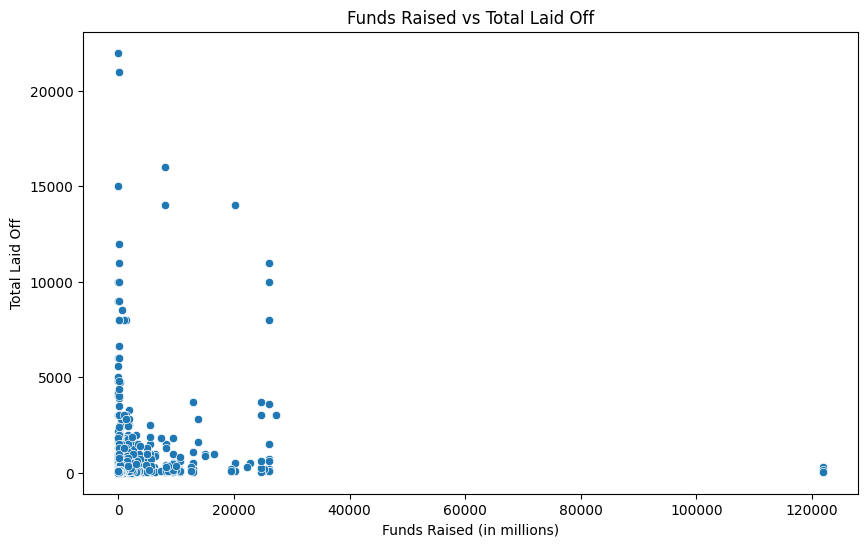

In [22]:
#funding vs layoffs scatterplot
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Funds_Raised',
    y='Total_Laid_Off',
    data=df
)
plt.title("Funds Raised vs Total Laid Off")
plt.xlabel("Funds Raised (in millions)")
plt.ylabel("Total Laid Off")
plt.savefig('funding_vs_layoffs_scatterplot.png')
plt.show()

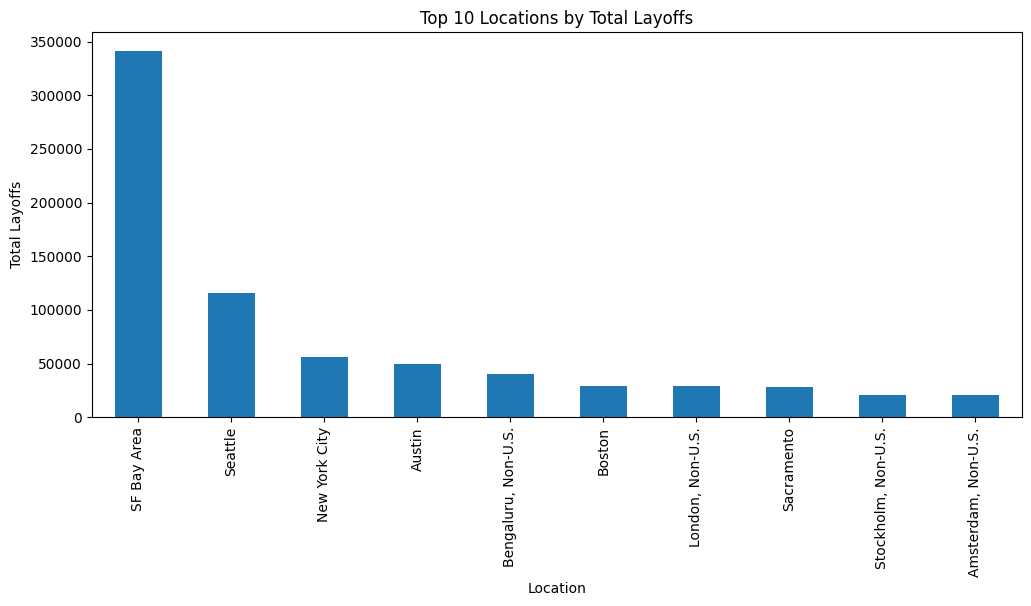

In [23]:
#location vs layoffs(top 10)
plt.figure(figsize=(12,5))
location=df.groupby("Location")["Total_Laid_Off"].sum().sort_values(ascending=False).head(10)
plt.xlabel('Location')
plt.ylabel('Total Layoffs')
plt.title("Top 10 Locations by Total Layoffs")
location.plot(kind='bar')
plt.savefig('location_layoffs.png')
plt.show()

In [24]:
# Top Companies
top_company = df.groupby("Company")["Total_Laid_Off"].sum().sort_values(ascending=False)

# Top Countries
top_country = df.groupby("Country")["Total_Laid_Off"].sum().sort_values(ascending=False)

# Top Industries
top_industry = df.groupby("Industry")["Total_Laid_Off"].sum().sort_values(ascending=False)

# Top Stages
top_stage = df.groupby("Stage")["Total_Laid_Off"].sum().sort_values(ascending=False)

# Year-wise Layoffs
yearly = df.groupby("Year")["Total_Laid_Off"].sum()

# Month-wise Layoffs
monthly = df.groupby("Month")["Total_Laid_Off"].sum()

# Correlation
corr = df[["Total_Laid_Off",
           "Percentage_Laid_Off",
           "Funds_Raised"]].corr()

# Write report
with open("EDA_Insights_Report.txt", "w", encoding="utf-8") as f:

    f.write("="*70 + "\n")
    f.write("        GLOBAL LAYOFFS DATASET - EDA INSIGHTS REPORT\n")
    f.write("="*70 + "\n\n")

    f.write(f"Total Records : {df.shape[0]}\n")
    f.write(f"Total Features: {df.shape[1]}\n\n")

    f.write("="*70 + "\n")
    f.write("TOP 10 COMPANIES WITH HIGHEST LAYOFFS\n")
    f.write("="*70 + "\n")
    f.write(top_company.head(10).to_string())
    f.write("\n\n")

    f.write("="*70 + "\n")
    f.write("TOP 10 COUNTRIES WITH HIGHEST LAYOFFS\n")
    f.write("="*70 + "\n")
    f.write(top_country.head(10).to_string())
    f.write("\n\n")

    f.write("="*70 + "\n")
    f.write("TOP INDUSTRIES AFFECTED\n")
    f.write("="*70 + "\n")
    f.write(top_industry.head(10).to_string())
    f.write("\n\n")

    f.write("="*70 + "\n")
    f.write("LAYOFFS BY COMPANY STAGE\n")
    f.write("="*70 + "\n")
    f.write(top_stage.to_string())
    f.write("\n\n")

    f.write("="*70 + "\n")
    f.write("YEAR-WISE LAYOFFS\n")
    f.write("="*70 + "\n")
    f.write(yearly.to_string())
    f.write("\n\n")

    f.write("="*70 + "\n")
    f.write("MONTH-WISE LAYOFFS\n")
    f.write("="*70 + "\n")
    f.write(monthly.to_string())
    f.write("\n\n")

    f.write("="*70 + "\n")
    f.write("CORRELATION MATRIX\n")
    f.write("="*70 + "\n")
    f.write(corr.to_string())
    f.write("\n\n")

    f.write("="*70 + "\n")
    f.write("KEY INSIGHTS\n")
    f.write("="*70 + "\n")

    f.write(f"• Company with highest layoffs : {top_company.idxmax()} ({int(top_company.max())} employees)\n")
    f.write(f"• Country with highest layoffs : {top_country.idxmax()} ({int(top_country.max())} employees)\n")
    f.write(f"• Industry most affected       : {top_industry.idxmax()} ({int(top_industry.max())} employees)\n")
    f.write(f"• Stage most affected          : {top_stage.idxmax()} ({int(top_stage.max())} employees)\n")
    f.write(f"• Peak layoff year             : {yearly.idxmax()} ({int(yearly.max())} employees)\n")
    f.write(f"• Peak layoff month            : {monthly.idxmax()} ({int(monthly.max())} employees)\n\n")

    f.write("Business Observations:\n")
    f.write("- Layoffs were concentrated in a few companies and industries.\n")
    f.write("- Technology and well-funded companies also experienced workforce reductions.\n")
    f.write("- The United States contributed the largest share of layoffs.\n")
    f.write("- Workforce reductions varied across different company stages.\n")
    f.write("- Exploratory Data Analysis revealed clear temporal and industry-specific trends.\n")

print("EDA_Insights_Report.txt generated successfully!")

EDA_Insights_Report.txt generated successfully!


In [25]:
df.to_csv('layoffs_cleaned.csv', index=False)